# Lab 1. What Is Natural Language Processing?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-01-what-is-nlp.ipynb)

This lab accompanies Chapter 1 of **Mathematical Natural Language Processing**.

The purpose of this first lab is not to use a large language model immediately.  The purpose is to understand the mathematical pipeline behind NLP:

$$
\text{raw text} \longrightarrow \text{tokens} \longrightarrow \text{vocabulary} \longrightarrow \text{vectors} \longrightarrow \text{model or score}.
$$

By the end of the lab, you should understand how ordinary sentences become arrays that Python can compute with.

## How to use this lab

This notebook is designed for independent study.

1. Read the short mathematical explanation before each code block.
2. Run each code cell in order.
3. When you see a **Try it yourself** prompt, change the data or parameters and rerun the cell.
4. At the end, complete the reflection questions in your own words.

No special installation is needed.  The lab uses only standard Python packages available in Google Colab.

## Learning goals

After completing this lab, you should be able to:

- represent text as a finite sequence of tokens;
- construct a vocabulary from a small corpus;
- build count vectors and a term-document matrix;
- explain what information is lost by a bag-of-words representation;
- compute a simple retrieval score using cosine similarity;
- connect a two-feature text representation to a logistic classifier;
- create simple next-token training pairs from a sentence.

## 1. Mathematical background: text as discrete data

Let $V$ be a finite vocabulary.  A sentence of length $T$ is a finite sequence

$$
x=(w_1,w_2,\ldots,w_T), \qquad w_t \in V.
$$

The set of all length-$T$ sequences is $V^T$.  The set of all finite token sequences is

$$
V^* = \bigcup_{T \geq 0} V^T.
$$

A key point is that $V^*$ is not automatically a vector space.  Before we can use linear algebra, statistics, or machine learning, we need a representation map

$$
\phi: V^* \longrightarrow R^d.
$$

In this lab, the first representation map will be a **count-vector map**.  If the vocabulary is ordered as

$$
V=\{v_1,v_2,\ldots,v_d\},
$$

then the $j$th coordinate of the count vector is

$$
\phi_j(x)=\#\{t: w_t=v_j\}.
$$

In words: coordinate $j$ counts how many times token $v_j$ appears in the document.

## 2. Setup

We import a small set of friendly tools:

- `re` for simple tokenization with regular expressions;
- `Counter` for counting tokens;
- `numpy` for arrays and vectors;
- `pandas` for readable tables;
- `matplotlib` for simple plots.

In [1]:
import re
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 3. A tiny corpus

A **corpus** is a collection of texts.  We begin with a tiny corpus so every object can be inspected by hand.

Mathematically, write

$$
D=\{x_1,x_2,x_3,x_4,x_5\}, \qquad x_i \in V^*.
$$

The corpus below is intentionally small and centered on language, mathematics, and data.

In [2]:
corpus = [
    "Machine learning models learn from data.",
    "Language models predict the next token.",
    "Statistics studies data uncertainty and models.",
    "Mathematics helps us understand language and computation.",
    "A retrieval system ranks documents for a query."
]

for i, doc in enumerate(corpus, start=1):
    print(f"x_{i}: {doc}")

x_1: Machine learning models learn from data.
x_2: Language models predict the next token.
x_3: Statistics studies data uncertainty and models.
x_4: Mathematics helps us understand language and computation.
x_5: A retrieval system ranks documents for a query.


## 4. Tokenization

A **token** is one unit of text.  Depending on the application, a token may be a word, punctuation mark, character, or subword.

In this first lab, we use a simple word-level tokenizer:

1. convert text to lowercase;
2. keep alphabetic words and numbers;
3. drop punctuation.

This is not the only possible tokenizer.  It is a transparent first choice.

In [3]:
def tokenize(text):
    """Simple word tokenizer for a first NLP lab.

    This function lowercases the text and extracts words/numbers.
    It intentionally avoids advanced NLP libraries so that the logic is visible.
    """
    return re.findall(r"[a-zA-Z]+|[0-9]+", text.lower())

# Tokenize every document.
tokenized_corpus = [tokenize(doc) for doc in corpus]

for i, tokens in enumerate(tokenized_corpus, start=1):
    print(f"tokens(x_{i}) = {tokens}")

tokens(x_1) = ['machine', 'learning', 'models', 'learn', 'from', 'data']
tokens(x_2) = ['language', 'models', 'predict', 'the', 'next', 'token']
tokens(x_3) = ['statistics', 'studies', 'data', 'uncertainty', 'and', 'models']
tokens(x_4) = ['mathematics', 'helps', 'us', 'understand', 'language', 'and', 'computation']
tokens(x_5) = ['a', 'retrieval', 'system', 'ranks', 'documents', 'for', 'a', 'query']


### Check the mathematical object

After tokenization, each document is a finite sequence:

$$
x_i = (w_1,w_2,\ldots,w_T).
$$

The length $T$ may be different for different documents.  Let us compute these lengths.

In [4]:
lengths = [len(tokens) for tokens in tokenized_corpus]

length_table = pd.DataFrame({
    "document": [f"x_{i}" for i in range(1, len(corpus) + 1)],
    "number_of_tokens": lengths
})

length_table

,document,number_of_tokens
0,x_1,6
1,x_2,6
2,x_3,6
3,x_4,7
4,x_5,8


## 5. Vocabulary construction

The **vocabulary** $V$ is the finite set of tokens that our representation knows about.

In a small lab, we can define $V$ as all distinct tokens appearing in the corpus.  For reproducibility, we sort the vocabulary alphabetically.  This gives a fixed coordinate order.

In [5]:
vocab = sorted(set(token for doc in tokenized_corpus for token in doc))
token_to_index = {token: j for j, token in enumerate(vocab)}

print("Vocabulary size d =", len(vocab))
print(vocab)

Vocabulary size d = 27
['a', 'and', 'computation', 'data', 'documents', 'for', 'from', 'helps', 'language', 'learn', 'learning', 'machine', 'mathematics', 'models', 'next', 'predict', 'query', 'ranks', 'retrieval', 'statistics', 'studies', 'system', 'the', 'token', 'uncertainty', 'understand', 'us']


The dictionary `token_to_index` tells us which coordinate belongs to which token.

For example, if `token_to_index["data"] = 5`, then the token `data` is represented by coordinate 5 in our vectors.

In [6]:
pd.DataFrame({
    "token": vocab,
    "coordinate_index": [token_to_index[token] for token in vocab]
}).head(20)

,token,coordinate_index
0,a,0
1,and,1
2,computation,2
3,data,3
4,documents,4
5,for,5
6,from,6
7,helps,7
8,language,8
9,learn,9


## 6. Count-vector representation

We now build the representation map

$$
\phi: V^* \longrightarrow R^d.
$$

For each document $x$, the vector $\phi(x)$ has length $d=|V|$.  Its $j$th coordinate counts the number of occurrences of token $v_j$ in $x$.

This representation is also called a **bag-of-words** representation because it counts words but ignores word order.

In [7]:
def count_vector(tokens, vocab):
    """Return the bag-of-words count vector for one tokenized document."""
    counts = Counter(tokens)
    return np.array([counts[token] for token in vocab], dtype=float)

X = np.vstack([count_vector(tokens, vocab) for tokens in tokenized_corpus])

print("Shape of X:", X.shape)
print("Rows = documents; columns = vocabulary tokens")

Shape of X: (5, 27)
Rows = documents; columns = vocabulary tokens


Let us display the count vectors as a table.  Each row is one document.  Each column is one vocabulary token.

In [8]:
count_df = pd.DataFrame(X, index=[f"x_{i}" for i in range(1, len(corpus) + 1)], columns=vocab)
count_df

,a,and,computation,data,documents,for,from,helps,language,learn,learning,machine,mathematics,models,next,predict,query,ranks,retrieval,statistics,studies,system,the,token,uncertainty,understand,us
x_1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
x_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
x_3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
x_4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
x_5,2.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### Inspect one document vector

The first document is

> Machine learning models learn from data.

Its count vector has one nonzero entry for each token that appears in the document.

In [9]:
doc_id = 0
nonzero = [(token, int(X[doc_id, j])) for j, token in enumerate(vocab) if X[doc_id, j] > 0]

print("Nonzero entries of phi(x_1):")
for token, count in nonzero:
    print(f"  {token:>12s}: {count}")

Nonzero entries of phi(x_1):
          data: 1
          from: 1
         learn: 1
      learning: 1
       machine: 1
        models: 1


## 7. The term-document matrix

In linear algebraic NLP, we often arrange count vectors into a matrix.

There are two common conventions:

1. document-by-term matrix: $X \in R^{n \times d}$;
2. term-document matrix: $X^T \in R^{d \times n}$.

Our `X` matrix has shape `(number of documents, vocabulary size)`, so it is a document-by-term matrix.

In [10]:
n, d = X.shape
print("Number of documents n =", n)
print("Vocabulary size d =", d)
print("Document-by-term matrix shape:", X.shape)
print("Term-document matrix shape:", X.T.shape)

Number of documents n = 5
Vocabulary size d = 27
Document-by-term matrix shape: (5, 27)
Term-document matrix shape: (27, 5)


The vector-space viewpoint begins here: each document is now a point in $R^d$.

The next plot shows token counts in the first document.

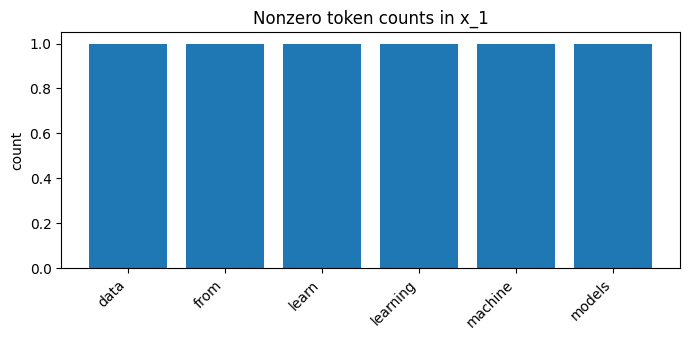

In [11]:
first_doc_counts = pd.Series(X[0], index=vocab)
first_doc_counts = first_doc_counts[first_doc_counts > 0].sort_values(ascending=False)

plt.figure(figsize=(7, 3.5))
plt.bar(first_doc_counts.index, first_doc_counts.values)
plt.ylabel("count")
plt.title("Nonzero token counts in x_1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. What bag-of-words loses

The bag-of-words map can be useful, but it loses order.

Consider the sentences:

- `dogs chase cats`
- `cats chase dogs`

These sentences have different meanings, but they contain the same tokens with the same counts.

In [12]:
sentence_a = "dogs chase cats"
sentence_b = "cats chase dogs"

pair = [sentence_a, sentence_b]
pair_tokens = [tokenize(s) for s in pair]
pair_vocab = sorted(set(token for doc in pair_tokens for token in doc))
pair_X = np.vstack([count_vector(tokens, pair_vocab) for tokens in pair_tokens])

pd.DataFrame(pair_X, index=["dogs chase cats", "cats chase dogs"], columns=pair_vocab)

,cats,chase,dogs
dogs chase cats,1.0,1.0,1.0
cats chase dogs,1.0,1.0,1.0


The two rows are identical.  Therefore, any model that only sees these count vectors must treat the two sentences as the same input.

This illustrates an important principle:

> A representation map decides what information is preserved and what information is discarded.

In [13]:
print("Are the two bag-of-words vectors equal?", np.array_equal(pair_X[0], pair_X[1]))

Are the two bag-of-words vectors equal? True


## 9. Simple retrieval with cosine similarity

A retrieval system receives a query $q$ and ranks documents $d_1,\ldots,d_n$ by a score.

A simple vector-space retrieval pipeline is

$$
q \mapsto \phi(q), \qquad d_i \mapsto \phi(d_i),
$$

then rank by cosine similarity:

$$
\cos(\phi(q),\phi(d_i))
=
\frac{\phi(q)^T\phi(d_i)}{\|\phi(q)\|\,\|\phi(d_i)\|}.
$$

Cosine similarity is large when two vectors point in similar directions.

In [14]:
def cosine_similarity(a, b):
    """Compute cosine similarity between two vectors."""
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return float(np.dot(a, b) / (norm_a * norm_b))

query = "language models and data"
query_tokens = tokenize(query)
query_vec = count_vector(query_tokens, vocab)

scores = [cosine_similarity(query_vec, X[i]) for i in range(n)]

ranking = pd.DataFrame({
    "document": [f"x_{i}" for i in range(1, n + 1)],
    "text": corpus,
    "cosine_score": scores
}).sort_values("cosine_score", ascending=False)

ranking

,document,text,cosine_score
2,x_3,Statistics studies data uncertainty and models.,0.612372
0,x_1,Machine learning models learn from data.,0.408248
1,x_2,Language models predict the next token.,0.408248
3,x_4,Mathematics helps us understand language and c...,0.377964
4,x_5,A retrieval system ranks documents for a query.,0.000000


### Interpretation

The ranking is not based on deep understanding.  It is based only on token overlap after count-vector representation.

Still, this simple example already has the mathematical structure of retrieval:

$$
\text{query} \longrightarrow \text{query vector} \longrightarrow \text{similarity scores} \longrightarrow \text{ranked documents}.
$$

**Try it yourself.** Change the query in the previous cell to one of the following and rerun it:

- `statistics uncertainty`
- `documents query retrieval`
- `mathematics computation language`

## 10. A two-feature text classifier

Chapter 1 introduces a small logistic classifier.  We will implement the same idea in Python.

Suppose we use only two features:

$$
\phi(x)=
\begin{bmatrix}
\text{count of positive words in } x \\
\text{count of negative words in } x
\end{bmatrix}.
$$

A logistic classifier computes

$$
z = \beta_0 + \beta_1 \phi_1(x) + \beta_2 \phi_2(x),
$$

and converts $z$ into a probability by

$$
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

The predicted class is positive if $\sigma(z) \geq 0.5$.

In [15]:
positive_words = {"good", "great", "excellent", "helpful", "clear", "useful", "love"}
negative_words = {"bad", "poor", "confusing", "unclear", "wrong", "unhelpful", "hate"}

sentiment_examples = [
    "This explanation is clear and helpful",
    "The model gives a wrong and confusing answer",
    "I love useful examples",
    "The instructions are unclear and unhelpful",
    "The lab is good but the notation is confusing"
]

def two_feature_representation(text):
    tokens = tokenize(text)
    pos_count = sum(token in positive_words for token in tokens)
    neg_count = sum(token in negative_words for token in tokens)
    return np.array([pos_count, neg_count], dtype=float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Chosen by hand for demonstration, not learned from data.
beta0 = 0.0
beta = np.array([1.2, -1.3])

rows = []
for text in sentiment_examples:
    phi = two_feature_representation(text)
    z = beta0 + np.dot(beta, phi)
    prob = sigmoid(z)
    rows.append({
        "text": text,
        "positive_count": int(phi[0]),
        "negative_count": int(phi[1]),
        "logit_z": z,
        "prob_positive": prob,
        "prediction": "positive" if prob >= 0.5 else "negative"
    })

pd.DataFrame(rows)

,text,positive_count,negative_count,logit_z,prob_positive,prediction
0,This explanation is clear and helpful,2,0,2.4,0.916827,positive
1,The model gives a wrong and confusing answer,0,2,-2.6,0.069138,negative
2,I love useful examples,2,0,2.4,0.916827,positive
3,The instructions are unclear and unhelpful,0,2,-2.6,0.069138,negative
4,The lab is good but the notation is confusing,1,1,-0.1,0.475021,negative


This is a complete miniature NLP classifier:

$$
\text{text} \longrightarrow \phi(x) \in R^2 \longrightarrow z \in R \longrightarrow \sigma(z) \in [0,1].
$$

It is too simple for real sentiment analysis, but it makes the mathematical pipeline visible.

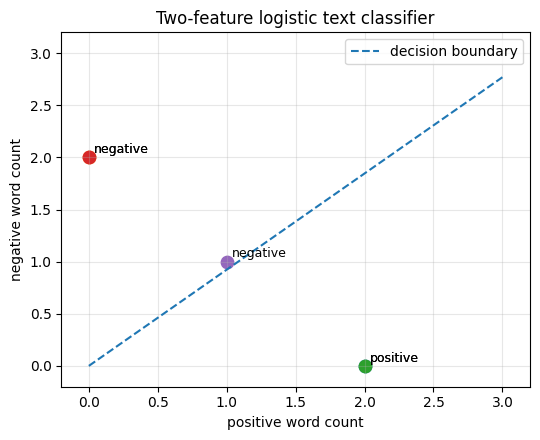

In [16]:
# Visualize the decision rule on a small grid of possible feature counts.
points = pd.DataFrame(rows)

plt.figure(figsize=(5.5, 4.5))
for _, row in points.iterrows():
    plt.scatter(row["positive_count"], row["negative_count"], s=80)
    plt.text(row["positive_count"] + 0.04, row["negative_count"] + 0.04, row["prediction"], fontsize=9)

# Decision boundary beta0 + beta1*x_pos + beta2*x_neg = 0.
x_pos = np.linspace(0, 3, 100)
x_neg = -(beta0 + beta[0] * x_pos) / beta[1]
plt.plot(x_pos, x_neg, linestyle="--", label="decision boundary")

plt.xlim(-0.2, 3.2)
plt.ylim(-0.2, 3.2)
plt.xlabel("positive word count")
plt.ylabel("negative word count")
plt.title("Two-feature logistic text classifier")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Next-token training pairs

Modern language models are often trained by next-token prediction.

Given a token sequence

$$
(w_1,w_2,\ldots,w_T),
$$

we can create training pairs of the form

$$
(w_1,\ldots,w_{t-1}) \mapsto w_t.
$$

For a first lab, we will create simple one-token-history pairs:

$$
w_{t-1} \mapsto w_t.
$$

This is the beginning of a bigram language model.

In [17]:
all_bigram_pairs = []

for doc_tokens in tokenized_corpus:
    for previous_token, next_token in zip(doc_tokens[:-1], doc_tokens[1:]):
        all_bigram_pairs.append((previous_token, next_token))

bigram_df = pd.DataFrame(all_bigram_pairs, columns=["previous_token", "next_token"])
bigram_df.head(15)

,previous_token,next_token
0,machine,learning
1,learning,models
2,models,learn
3,learn,from
4,from,data
5,language,models
6,models,predict
7,predict,the
8,the,next
9,next,token


We can estimate a simple conditional probability from counts:

$$
\widehat P(b \mid a)=\frac{\#(a,b)}{\#(a)}.
$$

This is a small version of statistical language modeling.

In [18]:
bigram_counts = Counter(all_bigram_pairs)
previous_counts = Counter(a for a, b in all_bigram_pairs)

def estimated_bigram_probability(previous_token, next_token):
    denominator = previous_counts[previous_token]
    if denominator == 0:
        return 0.0
    return bigram_counts[(previous_token, next_token)] / denominator

# Display all observed next-token distributions.
rows = []
for previous in sorted(previous_counts):
    next_options = sorted({b for a, b in bigram_counts if a == previous})
    for nxt in next_options:
        rows.append({
            "previous_token": previous,
            "next_token": nxt,
            "count": bigram_counts[(previous, nxt)],
            "estimated_probability": estimated_bigram_probability(previous, nxt)
        })

pd.DataFrame(rows).head(20)

,previous_token,next_token,count,estimated_probability
0,a,query,1,0.5
1,a,retrieval,1,0.5
2,and,computation,1,0.5
3,and,models,1,0.5
4,data,uncertainty,1,1.0
5,documents,for,1,1.0
6,for,a,1,1.0
7,from,data,1,1.0
8,helps,us,1,1.0
9,language,and,1,0.5


### Try one prediction context

Choose a previous token and list the observed next-token probabilities.

In [19]:
context = "models"

options = []
for (previous, nxt), count in bigram_counts.items():
    if previous == context:
        options.append((nxt, count, estimated_bigram_probability(previous, nxt)))

if options:
    print(f"Observed next tokens after '{context}':")
    for nxt, count, prob in sorted(options, key=lambda item: -item[2]):
        print(f"  {nxt:>12s}  count={count}  probability={prob:.3f}")
else:
    print(f"The context '{context}' was not observed in the corpus.")

Observed next tokens after 'models':
         learn  count=1  probability=0.500
       predict  count=1  probability=0.500


This example also shows a limitation.  If a context never appears in the training corpus, the unsmoothed estimate assigns no useful probabilities.  Later chapters discuss smoothing, embeddings, neural models, and transformers as increasingly powerful ways to share information across related contexts.

## 12. Independent practice

Complete the following tasks by editing the code cells below.

### Practice A: Create your own corpus

Write three to five sentences about a topic you know well.  Then tokenize them, build a vocabulary, and construct the count matrix.

In [20]:
# Practice A: replace these sentences with your own corpus.
my_corpus = [
    "Linear algebra studies vectors and matrices.",
    "Probability models uncertainty in data.",
    "Optimization helps train machine learning models."
]

my_tokenized = [tokenize(doc) for doc in my_corpus]
my_vocab = sorted(set(token for doc in my_tokenized for token in doc))
my_X = np.vstack([count_vector(tokens, my_vocab) for tokens in my_tokenized])

pd.DataFrame(my_X, index=[f"my_x_{i}" for i in range(1, len(my_corpus) + 1)], columns=my_vocab)

,algebra,and,data,helps,in,learning,linear,machine,matrices,models,optimization,probability,studies,train,uncertainty,vectors
my_x_1,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
my_x_2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
my_x_3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


### Practice B: Find two sentences with the same bag-of-words vector

Create two sentences with the same words but different order.  Verify that their count vectors are equal.

In [21]:
# Practice B: edit these examples.
s1 = "students use models"
s2 = "models use students"

practice_pair = [tokenize(s1), tokenize(s2)]
practice_vocab = sorted(set(token for tokens in practice_pair for token in tokens))
practice_X = np.vstack([count_vector(tokens, practice_vocab) for tokens in practice_pair])

print("Vocabulary:", practice_vocab)
print("Vectors are equal:", np.array_equal(practice_X[0], practice_X[1]))
pd.DataFrame(practice_X, index=[s1, s2], columns=practice_vocab)

Vocabulary: ['models', 'students', 'use']
Vectors are equal: True


,models,students,use
students use models,1.0,1.0,1.0
models use students,1.0,1.0,1.0


### Practice C: Modify the retrieval query

Use the original five-document corpus.  Choose a query and inspect the ranking.

In [22]:
# Practice C: edit this query.
my_query = "models uncertainty data"

my_query_vec = count_vector(tokenize(my_query), vocab)
my_scores = [cosine_similarity(my_query_vec, X[i]) for i in range(n)]

pd.DataFrame({
    "document": [f"x_{i}" for i in range(1, n + 1)],
    "text": corpus,
    "cosine_score": my_scores
}).sort_values("cosine_score", ascending=False)

,document,text,cosine_score
2,x_3,Statistics studies data uncertainty and models.,0.707107
0,x_1,Machine learning models learn from data.,0.471405
1,x_2,Language models predict the next token.,0.235702
3,x_4,Mathematics helps us understand language and c...,0.000000
4,x_5,A retrieval system ranks documents for a query.,0.000000


## 13. Reflection questions

Write answers in a markdown cell or in your course notes.

1. Why is a sentence not automatically a vector?
2. What is the difference between a vocabulary $V$ and a representation map $\phi$?
3. What information does bag-of-words preserve?  What information does it discard?
4. In the retrieval example, what made a document rank highly for a query?
5. Why does next-token prediction require probability rather than a single deterministic rule?
6. For a real university-resource chatbot, what would be the input space, document space, representation map, scoring function, and evaluation metric?

## 14. Lab summary

In this lab, you constructed the first mathematical objects of NLP:

| NLP idea | Mathematical or computational object |
|---|---|
| raw text | Python string |
| tokenized text | finite sequence $(w_1,\ldots,w_T)$ |
| vocabulary | finite set $V$ |
| document representation | vector $\phi(x) \in R^d$ |
| corpus representation | matrix $X \in R^{n \times d}$ |
| retrieval | similarity score between vectors |
| classification | map from features to a probability or label |
| next-token prediction | conditional probability estimate |

The central lesson is that NLP begins when we choose a representation map.  Every later model in the book, including neural networks and transformers, still depends on this basic pipeline.